# 3A Superstore Exploration with Polars and Plotly Express

This notebook explores the `3a-superstore` dataset from the local `data/raw/3a-superstore` folder. The dataset has order headers, order line details, customers, branches, and product categories.

The goal is not to build a final dashboard yet. It is to create a clean analytical base, check the core entities, and produce a few views that point to useful sales, CRM, marketing, and modeling work.

## Setup

Polars is used for fast lazy scanning and aggregation. Plotly Express is used after collecting small aggregated tables, which keeps the notebook responsive even when the raw order detail table is large.

In [1]:
from pathlib import Path

import polars as pl
import plotly.express as px

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(20)
pl.Config.set_fmt_str_lengths(60)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "3a-superstore"

REQUIRED_FILES = {
    "Branches": "Branches.csv",
    "Categories": "Categories.csv",
    "Customers": "Customers.csv",
    "Orders": "Orders.csv",
    "Order_Details": "Order_Details.csv",
}

missing = [file_name for file_name in REQUIRED_FILES.values() if not (RAW_DIR / file_name).exists()]
if missing:
    raise FileNotFoundError(f"Missing files in {RAW_DIR}: {missing}")

RAW_DIR

PosixPath('/Users/doruk/dev/3a-superstore-analysis/data/raw/3a-superstore')

## Load Tables Lazily

A few details matter for this dataset:

- `Customers.csv` uses semicolon separators.
- Currency-like values use decimal commas in `Orders.csv` and `Order_Details.csv`.
- `Order_Details.csv` is very large, so all joins and aggregations should stay lazy until the final `.collect()`.

In [2]:
csv_common = {
    "infer_schema_length": 10_000,
    "try_parse_dates": True,
    "low_memory": True,
    "decimal_comma": True,
}

branches = pl.scan_csv(RAW_DIR / "Branches.csv", **csv_common)
categories = pl.scan_csv(RAW_DIR / "Categories.csv", **csv_common)
customers = pl.scan_csv(RAW_DIR / "Customers.csv", separator=";", **csv_common)
orders = pl.scan_csv(RAW_DIR / "Orders.csv", **csv_common)
order_details = pl.scan_csv(RAW_DIR / "Order_Details.csv", **csv_common)

tables = {
    "Branches": branches,
    "Categories": categories,
    "Customers": customers,
    "Orders": orders,
    "Order_Details": order_details,
}

for name, lf in tables.items():
    print(f"\n{name}")
    print(lf.collect_schema())


Branches
Schema({'BRANCH_ID': String, 'REGION': String, 'CITY': String, 'TOWN': String, 'BRANCH_TOWN': String, 'LAT': Int64, 'LON': Int64})

Categories
Schema({'ITEMID': Int64, 'CATEGORY1': String, 'CATEGORY1_ID': Int64, 'CATEGORY2': String, 'CATEGORY2_ID': String, 'CATEGORY3': String, 'CATEGORY3_ID': String, 'CATEGORY4': String, 'CATEGORY4_ID': String, 'BRAND': String, 'ITEMCODE': Int64, 'ITEMNAME': String})

Customers
Schema({'USERID': Int64, 'USERNAME_': String, 'NAMESURNAME': String, 'STATUS_': Int64, 'USERGENDER': String, 'USERBIRTHDATE': Date, 'REGION': String, 'CITY': String, 'TOWN': String, 'DISTRICT': String, 'ADDRESSTEXT': String})

Orders
Schema({'ORDERID': Int64, 'BRANCH_ID': String, 'DATE_': Datetime(time_unit='us', time_zone=None), 'USERID': Int64, 'NAMESURNAME': String, 'TOTALBASKET': Float64})

Order_Details
Schema({'ORDERID': Int64, 'ORDERDETAILID': Int64, 'AMOUNT': Int64, 'UNITPRICE': Float64, 'TOTALPRICE': Float64, 'ITEMID': Int64, 'ITEMCODE': Int64})


In [3]:
# Small previews. These read only enough rows for display.
for name, lf in tables.items():
    print(f"\n{name}")
    display(lf.head(5).collect())


Branches


BRANCH_ID,REGION,CITY,TOWN,BRANCH_TOWN,LAT,LON
str,str,str,str,str,i64,i64
"""637-KA1""","""Karadeniz""","""Kastamonu""","""ABANA""","""SEYDİLER""",4197583330,3401138890
"""550-NE1""","""İç Anadolu""","""Nevşehir""","""ACIGÖL""","""NEVŞEHİR MERKEZ""",3855289060,3450575250
"""320-DE1""","""Ege""","""Denizli""","""ACIPAYAM""","""ACIPAYAM""",3743333330,2935000000
"""212-BI1""","""Doğu Anadolu""","""Bingöl""","""ADAKLI""","""BİNGÖL MERKEZ""",3922817760,4048339550
"""734-İS4""","""Marmara""","""İstanbul""","""ADALAR""","""SULTANBEYLİ""",4087637720,2909544400



Categories


ITEMID,CATEGORY1,CATEGORY1_ID,CATEGORY2,CATEGORY2_ID,CATEGORY3,CATEGORY3_ID,CATEGORY4,CATEGORY4_ID,BRAND,ITEMCODE,ITEMNAME
i64,str,i64,str,str,str,str,str,str,str,i64,str
1,"""EV""",627999999,"""ELEKTRIK-ELEKTRONIK""","""17-24312460""","""PIL""","""35-20121599""","""PIL""","""64-92313129""","""KODAK""",5,"""PIL KODAK XTRA HEAVY 9 V"""
2,"""EV""",627999999,"""ELEKTRIK-ELEKTRONIK""","""17-24312460""","""PIL""","""35-20121599""","""KALEM PILLER""","""64-60612924""","""KODAK""",6,"""PIL KODAK AA*2 MAX ALKALIN KALEM"""
3,"""OYUNCAK""",182825173,"""ZEKA GELISTIRICI""","""25-43246023""","""OYUNCAKLAR""","""78-18282517""","""BEBE OYUNCAK""","""158-416611223""","""OYUNCAK""",9,"""PILLI SESLI UCAK"""
4,"""OYUNCAK""",182825173,"""ZEKA GELISTIRICI""","""25-43246023""","""OYUNCAKLAR""","""78-18282517""","""BEBE OYUNCAK""","""158-416611223""","""OYUNCAK""",11,"""VAKKUMLU TASIYICI TIR"""
5,"""OYUNCAK""",182825173,"""ZEKA GELISTIRICI""","""25-43246023""","""OYUNCAKLAR""","""78-18282517""","""BEBE OYUNCAK""","""158-416611223""","""OYUNCAK""",15,"""OYUNCAK KUT.4LU METAL CEK BIRAK"""



Customers


USERID,USERNAME_,NAMESURNAME,STATUS_,USERGENDER,USERBIRTHDATE,REGION,CITY,TOWN,DISTRICT,ADDRESSTEXT
i64,str,str,i64,str,date,str,str,str,str,str
1,"""atilla.keles24086@outlookerlab.com""","""Atilla Keleş""",1,"""E""",1965-03-29,"""İç Anadolu""","""Eskişehir""","""TEPEBAŞI""","""FATİH MAH.""","""FATİH MAH. ŞEHİT AHMET KOÇ SOKAK 26220 TEPEBAŞI/ESKİŞEHİR"""
2,"""zeynep.seyma.altun98278@outlookerlab.com""","""Zeynep Şeyma Altun""",1,"""K""",1980-09-23,"""Güneydoğu Anadolu""","""Mardin""","""KIZILTEPE""","""ARIKLI KÖYÜ""","""ARIKLI KÖYÜ MAH. KÖYÜN KENDİSİ 47400 KIZILTEPE/MARDİN"""
3,"""aysun.aydin80939@inboxplus.com""","""Aysun Aydın""",1,"""K""",1961-06-16,"""Marmara""","""İstanbul""","""ÇATALCA""","""FERHATPAŞA MAH.""","""FERHATPAŞA MAH. NAR SOKAK 34540 ÇATALCA/İSTANBUL"""
4,"""lara.cinar80899@outlookerlab.com""","""Lara Çınar""",1,"""K""",1955-12-21,"""Karadeniz""","""Rize""","""FINDIKLI""","""CENNET KÖYÜ""","""CENNET KÖYÜ MAH. DÜZ CADDESİ 53740 FINDIKLI/RİZE"""
5,"""gonul.seda.cetin85529@gmaileo.com""","""Gönül Seda Çetin""",1,"""K""",1986-08-09,"""Ege""","""İzmir""","""KİRAZ""","""CERİTLER KÖYÜ""","""CERİTLER KÖYÜ MAH. SÜLÜKLÜ MEVKİ 35890 KİRAZ/İZMİR"""



Orders


ORDERID,BRANCH_ID,DATE_,USERID,NAMESURNAME,TOTALBASKET
i64,str,datetime[μs],i64,str,f64
7905270,"""320-DE1""",2022-08-22 00:00:00,72946,"""Ali İlhan""",2637.55
8131447,"""56-AN4""",2022-06-05 00:00:00,58126,"""Aysun Dinç""",2262.06
10176430,"""348-MU1""",2023-01-02 00:00:00,41317,"""Taner Yavuz""",2195.54
8445704,"""39-AY3""",2021-01-28 00:00:00,39303,"""Esra Lara Keleş""",446.86
8616360,"""777-YA1""",2022-10-24 00:00:00,64870,"""Ela Çakır""",430.18



Order_Details


ORDERID,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE,ITEMID,ITEMCODE
i64,i64,i64,f64,f64,i64,i64
5523363,27622768,4,12.5,25.96,23667,40199
5503074,27521136,3,3.5,10.08,1324,2871
5582877,27921491,4,4.9,35.04,4735,17605
5571722,27865830,8,15.5,85.84,17179,32797
5635480,28184303,2,57.5,121.1,21009,34535


## Dataset Size and Coverage

Start with simple row counts and date coverage. These checks tell us the practical grain of each table and the period covered by the orders.

In [4]:
row_counts = pl.concat(
    [
        lf.select(
            pl.lit(name).alias("table"),
            pl.len().alias("rows"),
        )
        for name, lf in tables.items()
    ],
    how="vertical",
).collect().sort("rows", descending=True)

row_counts

table,rows
str,u32
"""Order_Details""",51185032
"""Orders""",10235193
"""Customers""",99998
"""Categories""",27000
"""Branches""",957


In [5]:
order_coverage = (
    orders
    .select(
        pl.col("DATE_").min().alias("first_order_date"),
        pl.col("DATE_").max().alias("last_order_date"),
        pl.col("ORDERID").n_unique().alias("orders"),
        pl.col("USERID").n_unique().alias("customers_with_orders"),
        pl.col("BRANCH_ID").n_unique().alias("branches_with_orders"),
        pl.col("TOTALBASKET").sum().alias("sales"),
        pl.col("TOTALBASKET").mean().alias("avg_basket"),
    )
    .collect()
)

order_coverage

first_order_date,last_order_date,orders,customers_with_orders,branches_with_orders,sales,avg_basket
datetime[μs],datetime[μs],u32,u32,u32,f64,f64
2021-01-01 00:00:00,2023-08-14 00:00:00,10235193,99996,161,1.3106e10,1280.451429


## Build an Analysis-Ready Order View

`Branches.csv` has multiple rows per `BRANCH_ID` because a branch can cover multiple towns. Before joining branch attributes into orders, collapse it to one row per branch to avoid duplicating order rows and inflating sales.

The order view below adds customer and branch attributes plus month, year, and weekday fields that are useful for time-series and seasonality analysis.

In [6]:
branch_dim = (
    branches
    .group_by("BRANCH_ID")
    .agg(
        pl.col("REGION").first().alias("branch_region"),
        pl.col("CITY").first().alias("branch_city"),
        pl.col("BRANCH_TOWN").first().alias("branch_town"),
        pl.col("TOWN").n_unique().alias("covered_towns"),
        (pl.col("LAT").mean() / 100_000_000).alias("lat"),
        (pl.col("LON").mean() / 100_000_000).alias("lon"),
    )
)

orders_enriched = (
    orders
    .select("ORDERID", "BRANCH_ID", "DATE_", "USERID", "TOTALBASKET")
    .with_columns(
        pl.col("DATE_").cast(pl.Date).alias("order_date"),
        pl.col("DATE_").dt.truncate("1mo").cast(pl.Date).alias("order_month"),
        pl.col("DATE_").dt.year().alias("order_year"),
        pl.col("DATE_").dt.weekday().alias("order_weekday"),
    )
    .join(
        customers.select(
            "USERID",
            pl.col("USERGENDER").alias("customer_gender"),
            pl.col("USERBIRTHDATE").alias("birth_date"),
            pl.col("REGION").alias("customer_region"),
            pl.col("CITY").alias("customer_city"),
        ),
        on="USERID",
        how="left",
    )
    .join(branch_dim, on="BRANCH_ID", how="left")
)

orders_enriched.head(5).collect()

ORDERID,BRANCH_ID,DATE_,USERID,TOTALBASKET,order_date,order_month,order_year,order_weekday,customer_gender,birth_date,customer_region,customer_city,branch_region,branch_city,branch_town,covered_towns,lat,lon
i64,str,datetime[μs],i64,f64,date,date,i32,i8,str,date,str,str,str,str,str,u32,f64,f64
7905270,"""320-DE1""",2022-08-22 00:00:00,72946,2637.55,2022-08-22,2022-08-01,2022,1,"""E""",1978-03-01,"""Ege""","""Denizli""","""Ege""","""Denizli""","""ACIPAYAM""",4,37.326755,29.2186
8131447,"""56-AN4""",2022-06-05 00:00:00,58126,2262.06,2022-06-05,2022-06-01,2022,7,"""K""",1973-12-31,"""İç Anadolu""","""Ankara""","""İç Anadolu""","""Ankara""","""YENİMAHALLE""",8,40.054681,32.617896
10176430,"""348-MU1""",2023-01-02 00:00:00,41317,2195.54,2023-01-02,2023-01-01,2023,1,"""E""",1959-11-09,"""Ege""","""Muğla""","""Ege""","""Muğla""","""BODRUM""",3,37.025472,27.633045
8445704,"""39-AY3""",2021-01-28 00:00:00,39303,446.86,2021-01-28,2021-01-01,2021,4,"""K""",1974-08-13,"""Ege""","""Aydın""","""Ege""","""Aydın""","""NAZİLLİ""",9,37.820038,28.323201
8616360,"""777-YA1""",2022-10-24 00:00:00,64870,430.18,2022-10-24,2022-10-01,2022,1,"""K""",1967-07-16,"""Marmara""","""Yalova""","""Marmara""","""Yalova""","""YALOVA MERKEZ""",6,40.628852,29.201874


## Sales Trend

Monthly sales and order counts are the first read on growth, seasonality, and changes in average basket size.

In [7]:
monthly_sales = (
    orders_enriched
    .group_by("order_month")
    .agg(
        pl.col("TOTALBASKET").sum().alias("sales"),
        pl.len().alias("orders"),
        pl.col("USERID").n_unique().alias("customers"),
    )
    .with_columns((pl.col("sales") / pl.col("orders")).alias("avg_basket"))
    .sort("order_month")
    .collect()
)

monthly_sales.head()

order_month,sales,orders,customers,avg_basket
date,f64,u32,u32,f64
2021-01-01,2.6237e8,332774,96537,788.447233
2021-02-01,2.4535e8,300211,94975,817.252459
2021-03-01,2.8055e8,332385,96373,844.044446
2021-04-01,2.8120e8,321862,96019,873.665243
2021-05-01,3.0071e8,332218,96317,905.160763


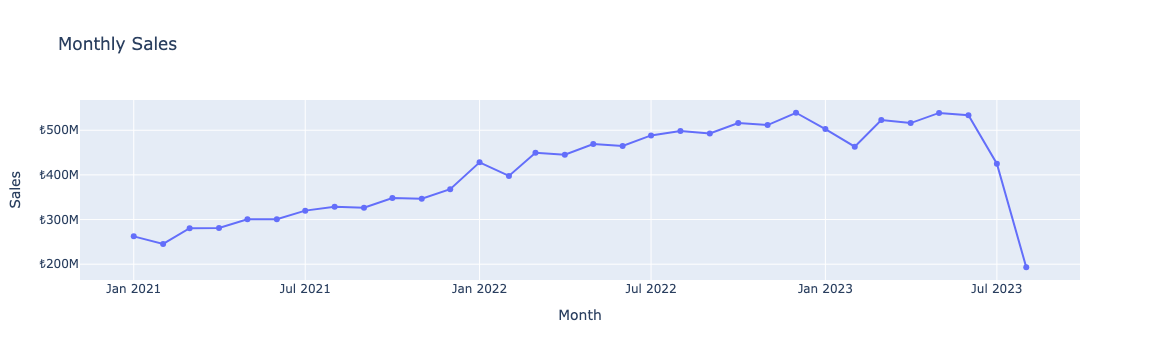

In [8]:
fig = px.line(
    monthly_sales,
    x="order_month",
    y="sales",
    markers=True,
    title="Monthly Sales",
    labels={"order_month": "Month", "sales": "Sales"},
)
fig.update_layout(yaxis_tickprefix="₺", hovermode="x unified")
fig.show()

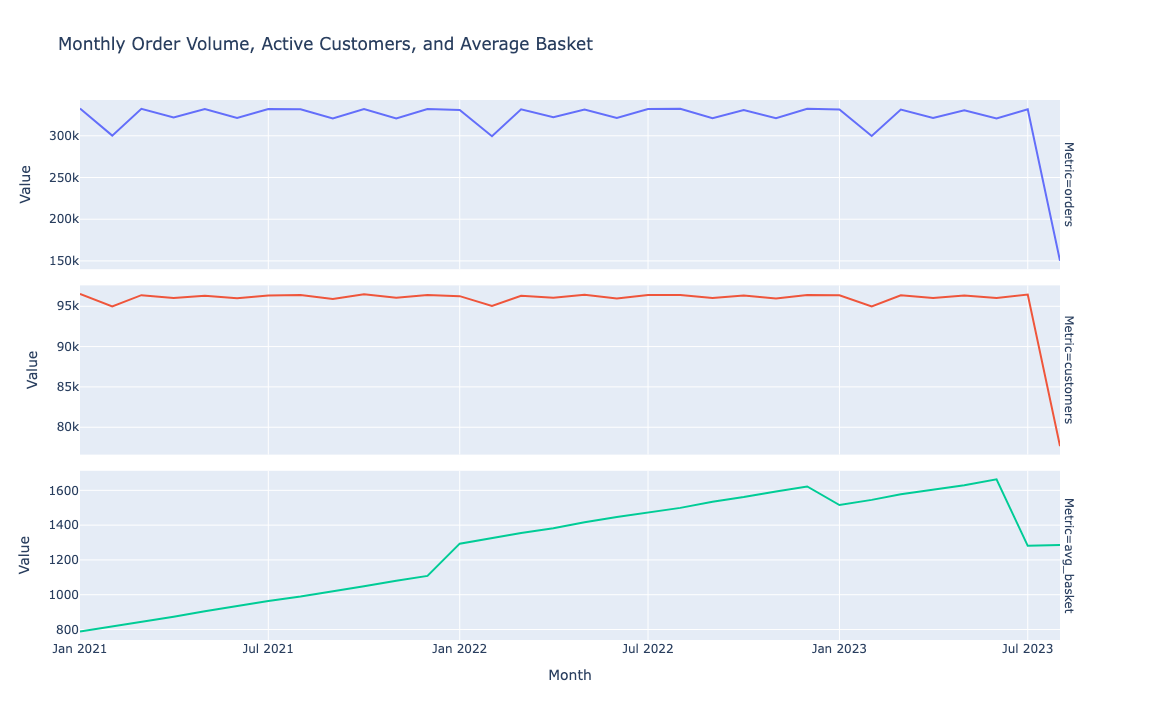

In [9]:
monthly_long = monthly_sales.unpivot(
    index="order_month",
    on=["orders", "customers", "avg_basket"],
    variable_name="metric",
    value_name="value",
)

fig = px.line(
    monthly_long,
    x="order_month",
    y="value",
    color="metric",
    facet_row="metric",
    title="Monthly Order Volume, Active Customers, and Average Basket",
    labels={"order_month": "Month", "value": "Value", "metric": "Metric"},
    height=720,
)
fig.update_yaxes(matches=None)
fig.update_layout(showlegend=False, hovermode="x unified")
fig.show()

## Branch and Regional Performance

Branch-level views help compare store footprint, revenue concentration, and average basket differences by region and city.

In [10]:
region_sales = (
    orders_enriched
    .group_by("branch_region")
    .agg(
        pl.col("TOTALBASKET").sum().alias("sales"),
        pl.len().alias("orders"),
        pl.col("USERID").n_unique().alias("customers"),
        pl.col("BRANCH_ID").n_unique().alias("branches"),
    )
    .with_columns(
        (pl.col("sales") / pl.col("orders")).alias("avg_basket"),
        (pl.col("sales") / pl.col("branches")).alias("sales_per_branch"),
    )
    .sort("sales", descending=True)
    .collect()
)

region_sales

branch_region,sales,orders,customers,branches,avg_basket,sales_per_branch
str,f64,u32,u32,u32,f64,f64
"""Marmara""",3.8151e9,2979605,29122,23,1280.398852,1.6587e8
"""İç Anadolu""",2.0919e9,1634377,15962,25,1279.965011,8.3678e7
"""Ege""",1.8936e9,1477770,14444,24,1281.417055,7.8902e7
"""Akdeniz""",1.6703e9,1302153,12724,22,1282.714982,7.5922e7
"""Güneydoğu Anadolu""",1.4242e9,1113600,10873,20,1278.882949,7.1208e7
"""Karadeniz""",1.2447e9,971622,9489,27,1281.097452,4.6102e7
"""Doğu Anadolu""",9.6580e8,756066,7382,20,1277.404277,4.8290e7


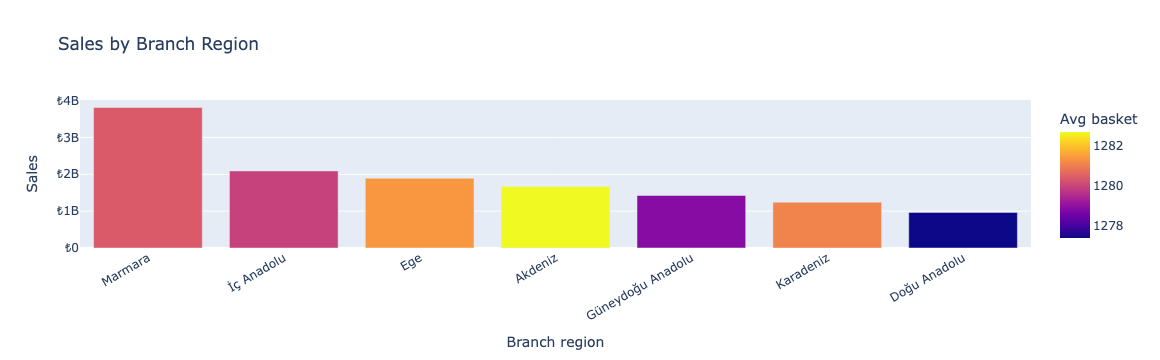

In [11]:
fig = px.bar(
    region_sales,
    x="branch_region",
    y="sales",
    color="avg_basket",
    title="Sales by Branch Region",
    labels={"branch_region": "Branch region", "sales": "Sales", "avg_basket": "Avg basket"},
)
fig.update_layout(xaxis_tickangle=-30, yaxis_tickprefix="₺")
fig.show()

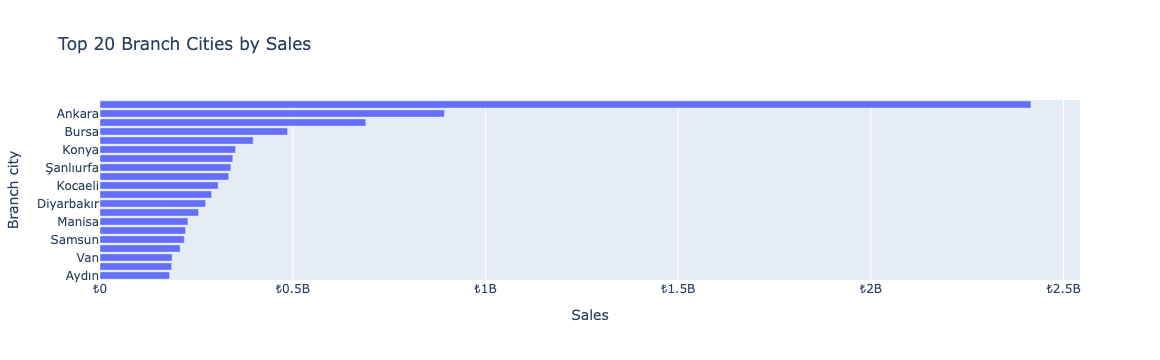

In [12]:
top_branch_cities = (
    orders_enriched
    .group_by("branch_city")
    .agg(
        pl.col("TOTALBASKET").sum().alias("sales"),
        pl.len().alias("orders"),
        pl.col("BRANCH_ID").n_unique().alias("branches"),
    )
    .with_columns((pl.col("sales") / pl.col("branches")).alias("sales_per_branch"))
    .sort("sales", descending=True)
    .head(20)
    .collect()
)

fig = px.bar(
    top_branch_cities.sort("sales"),
    x="sales",
    y="branch_city",
    orientation="h",
    title="Top 20 Branch Cities by Sales",
    labels={"sales": "Sales", "branch_city": "Branch city"},
)
fig.update_layout(xaxis_tickprefix="₺")
fig.show()

## Product Category Mix

Order details connect baskets to products. The next view joins line items to category metadata and ranks high-level categories by line revenue and unit volume.

In [13]:
line_items = (
    order_details
    .select("ORDERID", "ITEMID", "AMOUNT", "UNITPRICE", "TOTALPRICE")
    .join(
        categories.select("ITEMID", "CATEGORY1", "CATEGORY2", "CATEGORY3", "CATEGORY4", "BRAND", "ITEMNAME"),
        on="ITEMID",
        how="left",
    )
)

category_sales = (
    line_items
    .group_by("CATEGORY1")
    .agg(
        pl.col("TOTALPRICE").sum().alias("line_sales"),
        pl.col("AMOUNT").sum().alias("units"),
        pl.len().alias("lines"),
        pl.col("ITEMID").n_unique().alias("items"),
    )
    .with_columns(
        (pl.col("line_sales") / pl.col("lines")).alias("avg_line_value"),
        (pl.col("units") / pl.col("lines")).alias("avg_units_per_line"),
    )
    .sort("line_sales", descending=True)
    .collect()
)

category_sales

CATEGORY1,line_sales,units,lines,items,avg_line_value,avg_units_per_line
str,f64,i64,u32,u32,f64,f64
"""EV""",3.4307e9,83954870,18654547,9842,183.90731,4.500504
"""OYUNCAK""",2.8687e9,19037560,4232029,2232,677.860777,4.498447
"""KOZMETIK""",1.9331e9,27371304,6082890,3208,317.79676,4.49972
"""GIDA""",9.2028e8,26525911,5895180,3110,156.107175,4.499593
"""BEBEK""",6.5638e8,7405147,1645018,869,399.009984,4.50156
"""DETERJAN""",6.4240e8,7155360,1590021,838,404.020242,4.500167
…,…,…,…,…,…,…
"""MANAV""",4.1444e7,2337847,519743,274,79.7399,4.498083
"""KARO""",4.0637e7,349193,77746,41,522.691816,4.491459


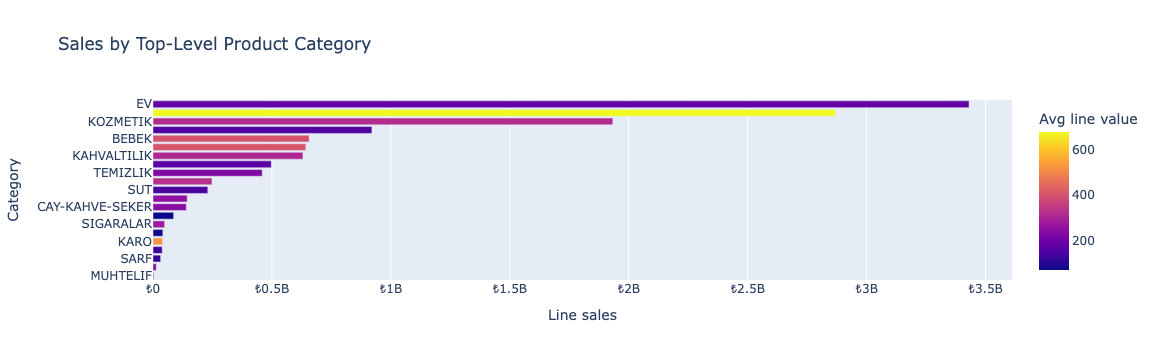

In [14]:
fig = px.bar(
    category_sales.sort("line_sales"),
    x="line_sales",
    y="CATEGORY1",
    orientation="h",
    color="avg_line_value",
    title="Sales by Top-Level Product Category",
    labels={"line_sales": "Line sales", "CATEGORY1": "Category", "avg_line_value": "Avg line value"},
)
fig.update_layout(xaxis_tickprefix="₺")
fig.show()

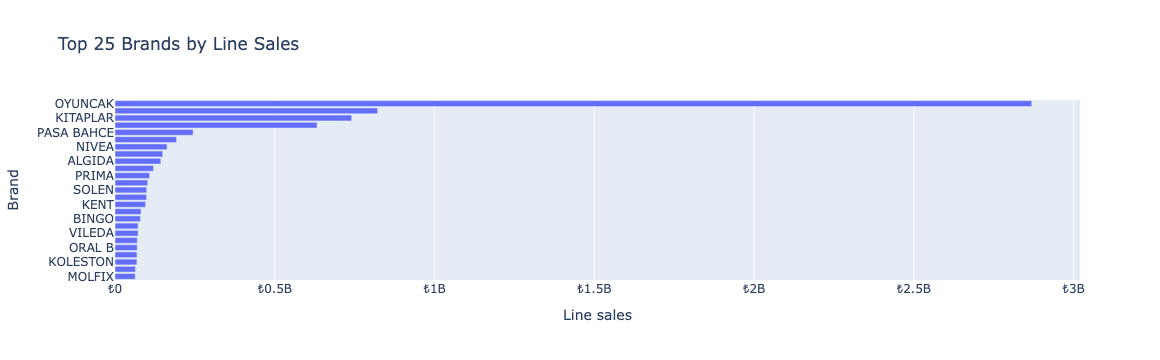

In [15]:
top_brands = (
    line_items
    .filter(pl.col("BRAND").is_not_null())
    .group_by("BRAND")
    .agg(
        pl.col("TOTALPRICE").sum().alias("line_sales"),
        pl.col("AMOUNT").sum().alias("units"),
        pl.col("ITEMID").n_unique().alias("items"),
    )
    .sort("line_sales", descending=True)
    .head(25)
    .collect()
)

fig = px.bar(
    top_brands.sort("line_sales"),
    x="line_sales",
    y="BRAND",
    orientation="h",
    title="Top 25 Brands by Line Sales",
    labels={"line_sales": "Line sales", "BRAND": "Brand"},
)
fig.update_layout(xaxis_tickprefix="₺")
fig.show()

## Customer Value and CRM Signals

A lightweight RFM table summarizes recency, frequency, and monetary value. This is a practical starting point for CRM segmentation, retention analysis, and customer-level modeling.

In [16]:
max_order_date = orders.select(pl.col("DATE_").max().cast(pl.Date).alias("max_date")).collect().item()

customer_rfm = (
    orders_enriched
    .group_by("USERID")
    .agg(
        pl.col("order_date").max().alias("last_order_date"),
        pl.col("ORDERID").n_unique().alias("frequency"),
        pl.col("TOTALBASKET").sum().alias("monetary"),
        pl.col("TOTALBASKET").mean().alias("avg_basket"),
        pl.col("customer_gender").first().alias("gender"),
        pl.col("customer_region").first().alias("region"),
        pl.col("customer_city").first().alias("city"),
    )
    .with_columns((pl.lit(max_order_date) - pl.col("last_order_date")).dt.total_days().alias("recency_days"))
    .sort("monetary", descending=True)
    .collect()
)

customer_rfm.head(10)

USERID,last_order_date,frequency,monetary,avg_basket,gender,region,city,recency_days
i64,date,u32,f64,f64,str,str,str,i64
2896,2023-08-14,113,482653.81,4271.272655,"""K""","""İç Anadolu""","""Sivas""",0
9343,2023-08-12,130,440095.36,3385.348923,"""K""","""Ege""","""Balıkesir""",2
13804,2023-08-04,97,430355.06,4436.650103,"""E""","""Doğu Anadolu""","""Kars""",10
67937,2023-08-09,107,405833.01,3792.831869,"""E""","""İç Anadolu""","""Ankara""",5
50027,2023-08-14,115,404058.87,3513.555391,"""K""","""Ege""","""İzmir""",0
13731,2023-08-13,112,391927.64,3499.353929,"""K""","""İç Anadolu""","""Nevşehir""",1
82998,2023-08-06,101,386513.65,3826.867822,"""E""","""Marmara""","""İstanbul""",8
91783,2023-07-30,97,366652.04,3779.917938,"""K""","""İç Anadolu""","""Ankara""",15
95489,2023-08-04,110,358893.21,3262.665545,"""E""","""Marmara""","""İstanbul""",10


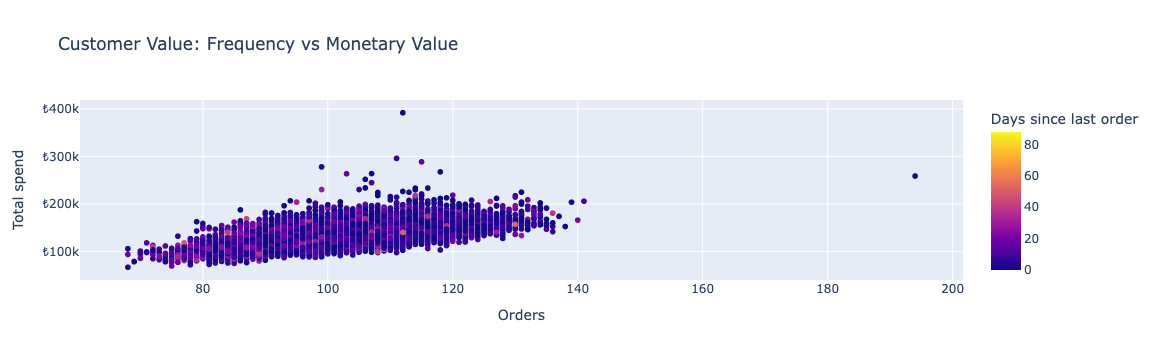

In [17]:
rfm_sample = customer_rfm.sample(n=min(20_000, customer_rfm.height), seed=42)

fig = px.scatter(
    rfm_sample,
    x="frequency",
    y="monetary",
    color="recency_days",
    hover_data=["USERID", "avg_basket", "region", "city"],
    title="Customer Value: Frequency vs Monetary Value",
    labels={"frequency": "Orders", "monetary": "Total spend", "recency_days": "Days since last order"},
)
fig.update_layout(yaxis_tickprefix="₺")
fig.show()

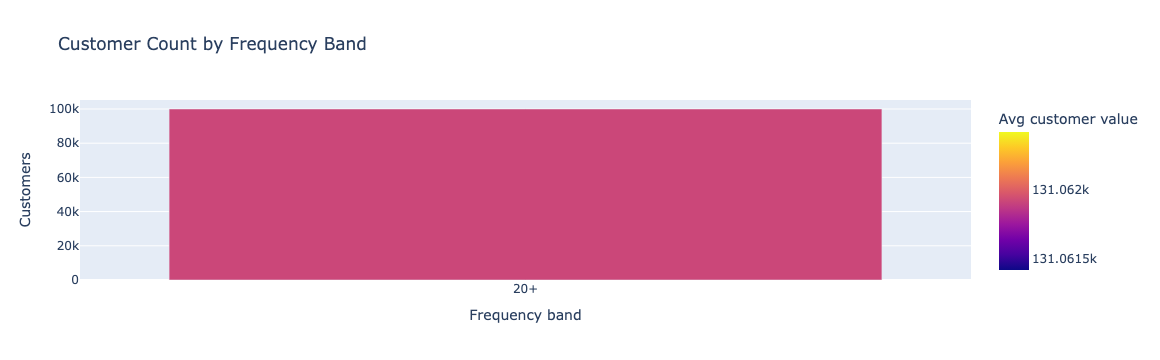

frequency_band,customers,sales,avg_customer_value,median_recency_days
str,u32,f64,f64,f64
"""20+""",99996,1.3106e10,131061.917511,6.0


In [18]:
rfm_bins = (
    customer_rfm
    .with_columns(
        pl.when(pl.col("frequency") >= 20).then(pl.lit("20+"))
        .when(pl.col("frequency") >= 10).then(pl.lit("10-19"))
        .when(pl.col("frequency") >= 5).then(pl.lit("5-9"))
        .otherwise(pl.lit("1-4"))
        .alias("frequency_band"),
    )
    .group_by("frequency_band")
    .agg(
        pl.len().alias("customers"),
        pl.col("monetary").sum().alias("sales"),
        pl.col("monetary").mean().alias("avg_customer_value"),
        pl.col("recency_days").median().alias("median_recency_days"),
    )
    .sort("frequency_band")
)

fig = px.bar(
    rfm_bins,
    x="frequency_band",
    y="customers",
    color="avg_customer_value",
    title="Customer Count by Frequency Band",
    labels={"frequency_band": "Frequency band", "customers": "Customers", "avg_customer_value": "Avg customer value"},
)
fig.show()

rfm_bins

## Basket and Cross-Sell Starters

The data can support basket analysis because each order has multiple line items. Start with basket size, then move to co-occurrence or association rules if needed.

In [19]:
basket_summary = (
    order_details
    .group_by("ORDERID")
    .agg(
        pl.col("ITEMID").n_unique().alias("unique_items"),
        pl.col("AMOUNT").sum().alias("units"),
        pl.col("TOTALPRICE").sum().alias("line_sales"),
    )
    .with_columns(
        pl.when(pl.col("unique_items") >= 10).then(pl.lit("10+"))
        .when(pl.col("unique_items") >= 5).then(pl.lit("5-9"))
        .when(pl.col("unique_items") >= 3).then(pl.lit("3-4"))
        .otherwise(pl.lit("1-2"))
        .alias("basket_size_band")
    )
    .group_by("basket_size_band")
    .agg(
        pl.len().alias("orders"),
        pl.col("line_sales").sum().alias("sales"),
        pl.col("line_sales").mean().alias("avg_basket_sales"),
        pl.col("units").mean().alias("avg_units"),
    )
    .sort("basket_size_band")
    .collect()
)

basket_summary

basket_size_band,orders,sales,avg_basket_sales,avg_units
str,u32,f64,f64,f64
"""1-2""",2273438,8.7421e8,384.533653,6.752594
"""3-4""",2273992,2.0379e9,896.158376,15.752274
"""5-9""",5687763,1.0194e10,1792.197936,31.497668


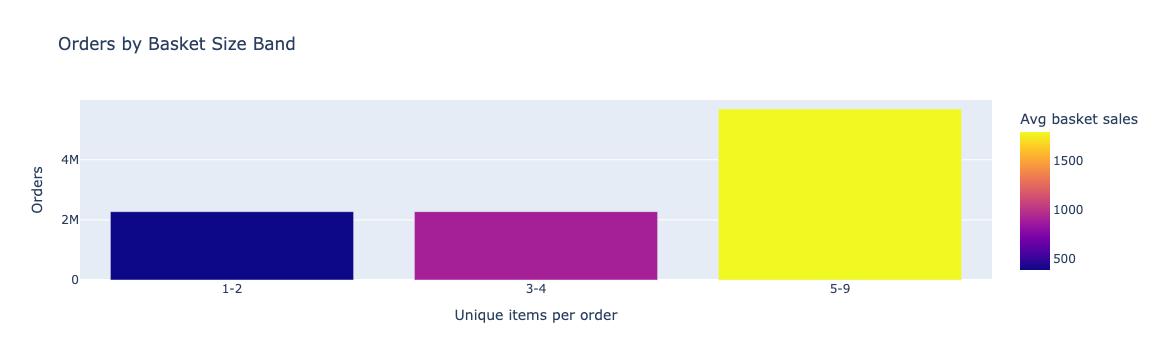

In [20]:
fig = px.bar(
    basket_summary,
    x="basket_size_band",
    y="orders",
    color="avg_basket_sales",
    title="Orders by Basket Size Band",
    labels={"basket_size_band": "Unique items per order", "orders": "Orders", "avg_basket_sales": "Avg basket sales"},
)
fig.show()

## Data Quality Checks

Before deeper analysis, validate missing join keys, suspicious dates, and whether order header totals reconcile with line totals. A small mismatch can come from tax, rounding, discounts, or data generation logic; a large mismatch needs investigation.

In [21]:
null_checks = pl.concat(
    [
        lf.select(
            pl.lit(name).alias("table"),
            *[pl.col(col).is_null().sum().alias(col) for col in lf.collect_schema().names()]
        )
        for name, lf in tables.items()
    ],
    how="diagonal_relaxed",
).collect()

null_checks

table,BRANCH_ID,REGION,CITY,TOWN,BRANCH_TOWN,LAT,LON,ITEMID,CATEGORY1,…,USERBIRTHDATE,DISTRICT,ADDRESSTEXT,ORDERID,DATE_,TOTALBASKET,ORDERDETAILID,AMOUNT,UNITPRICE,TOTALPRICE
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,…,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""Branches""",0,0,0,0,0,0,0,null,null,…,null,null,null,null,null,null,null,null,null,null
"""Categories""",null,null,null,null,null,null,null,0,0,…,null,null,null,null,null,null,null,null,null,null
"""Customers""",null,0,0,0,null,null,null,null,null,…,0,0,0,null,null,null,null,null,null,null
"""Orders""",0,null,null,null,null,null,null,null,null,…,null,null,null,0,0,0,null,null,null,null
"""Order_Details""",null,null,null,null,null,null,null,0,null,…,null,null,null,0,null,null,0,0,0,0


In [22]:
order_line_reconciliation = (
    orders.select("ORDERID", "TOTALBASKET")
    .join(
        order_details.group_by("ORDERID").agg(pl.col("TOTALPRICE").sum().alias("line_total")),
        on="ORDERID",
        how="left",
    )
    .with_columns((pl.col("TOTALBASKET") - pl.col("line_total")).alias("basket_line_diff"))
    .select(
        pl.len().alias("orders_checked"),
        pl.col("basket_line_diff").mean().alias("mean_diff"),
        pl.col("basket_line_diff").median().alias("median_diff"),
        pl.col("basket_line_diff").abs().mean().alias("mean_abs_diff"),
        pl.col("basket_line_diff").abs().max().alias("max_abs_diff"),
    )
    .collect()
)

order_line_reconciliation

orders_checked,mean_diff,median_diff,mean_abs_diff,max_abs_diff
u32,f64,f64,f64,f64
10235193,3.3644e-17,0.0,6.0993e-14,5.8208e-11


## Where to Take This Analysis Next

**Sales analysis:** track revenue, orders, average basket, units, category mix, brand mix, branch/city/region performance, seasonality, and basket composition. Useful KPIs include sales growth, orders, average order value, units per order, revenue per branch, category share, top/bottom products, and repeat purchase rate.

**CRM analysis:** build customer-level features such as recency, frequency, monetary value, average basket, preferred category, preferred branch/region, active months, and discount/promotion response if campaign data is later added. Relevant KPIs include active customers, new vs returning customers, churn risk, customer lifetime value proxy, repeat rate, purchase frequency, and customer value bands.

**Marketing analysis:** use geography, categories, brands, and customer segments to guide targeting. Relevant questions include which categories drive repeat visits, which regions over-index on certain categories, where high-value customers are concentrated, and what cross-sell bundles appear in baskets.

**Useful transformations:** parse dates, standardize decimal-comma numeric fields, normalize Turkish text if matching or grouping names, join order headers to details/products/customers/branches, create time grains, create age or age bands from birth date, reconcile basket totals, and aggregate customer/product/branch/month feature tables.

**Modeling ideas:** customer clustering with RFM and category-affinity features using k-means, Gaussian mixtures, or hierarchical clustering; churn or next-purchase propensity with logistic regression, tree models, or gradient boosting; sales forecasting by month/category/branch with baseline seasonal models, Prophet-style models, ARIMA/SARIMAX, or gradient boosting with lag features; basket recommendations with association rules such as Apriori/FP-Growth or item-item similarity; customer lifetime value proxies with regression or survival-style methods if observation windows are well defined.

Keep the next step focused: choose one business question, define the grain of the modeling table, then build only the features needed for that question.

## Inflation Adjustment for Real Sales Analysis

This dataset covers Türkiye from 2021-01-01 to 2023-08-14, a period with very high inflation. Sales fields such as `TOTALBASKET`, `TOTALPRICE`, and `UNITPRICE` should be treated as nominal TRY. Nominal sales growth is not the same thing as real business growth: it can reflect higher prices rather than more orders, more units, or stronger demand.

The standard approach is to keep the transaction currency as TRY and deflate nominal monetary values with a monthly consumer price index. Use monthly CPI rather than annual CPI because the order data has daily dates and the notebook already aggregates to month.

Choose a base month, such as the last complete month in the dataset (`2023-07`) or a stable reporting month such as `2023-06`. Then convert each nominal value into constant-TRY values:

```text
inflation_adjustment_factor = CPI_base_month / CPI_order_month
real_totalbasket = nominal_totalbasket * inflation_adjustment_factor
real_totalprice = nominal_totalprice * inflation_adjustment_factor
real_unitprice = nominal_unitprice * inflation_adjustment_factor
```

For monthly aggregates:

```text
nominal_sales_month = sum(TOTALBASKET)
real_sales_month = sum(TOTALBASKET * CPI_base_month / CPI_order_month)
real_avg_basket_month = real_sales_month / orders_month
real_growth_pct = real_sales_month / real_sales_previous_period - 1
nominal_growth_pct = nominal_sales_month / nominal_sales_previous_period - 1
```

A practical CPI join table only needs one row per month:

```text
order_month | cpi_index | inflation_adjustment_factor
2021-01     | ...       | CPI_base_month / CPI_2021_01
2021-02     | ...       | CPI_base_month / CPI_2021_02
...
```

Recommended sources:

- **TURKSTAT CPI:** the official source for Türkiye CPI. Best conceptual source for domestic real-sales analysis.
- **TCMB EVDS / TCMB Consumer Prices:** practical access point for TURKSTAT CPI series and monthly/yearly inflation rates. Use the CPI index level if available, not only year-over-year percentage changes.
- **IMF CPI dataset:** useful if the analysis needs internationally comparable CPI data or CPI component indexes.
- **World Bank CPI:** useful for annual context and cross-country comparisons, but too coarse for this notebook because it is annual rather than monthly.

Avoid using USD conversion as the main inflation adjustment. TRY-to-USD conversion answers a different question: the foreign-currency value of sales. It mixes domestic inflation with exchange-rate depreciation, interest-rate policy, capital flows, and currency-market shocks. It can be a secondary view, but the main real-growth analysis should use CPI-deflated TRY.

For this dataset, report real monetary metrics alongside inflation-resistant volume metrics:

- orders
- units sold
- unique customers
- nominal sales
- real sales
- nominal average basket
- real average basket
- category mix by units and by real sales
- branch and region performance by real sales per branch

Be careful with 2023 comparisons. The dataset ends on 2023-08-14, so August is partial. Also, July 2023 shows a sharp average-basket drop compared with June 2023, which should be checked before interpreting late-2023 trends as demand or inflation effects.

